In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.signal import butter, filtfilt, find_peaks


In [ ]:
ECG_data_1K = np.load('ECG_waveforms_1K.npy')
ECG_summary_1K = np.load('ECG_metrics_1K.npy')
Echo_1K = pd.read_csv('EchoNext_EchoData_5K.csv')

labels = Echo_1K['shd_moderate_or_greater_flag']


       Unnamed: 0   ecg_key  patient_key  age_at_ecg     sex  \
0               0   8520052    902618160          88    male   
1               1   7283576   4764241080          69  female   
2               2   8769869   4214459612          22    male   
3               3   6379904   6205191619          70    male   
4               4   9619545   8380688329          54    male   
...           ...       ...          ...         ...     ...   
9996         9996   7661879   6928544590          57  female   
9997         9997   5818925   8193877475          71  female   
9998         9998   8906200   5404075775          61    male   
9999         9999   8477393   5225334030          64    male   
10000       10000  10191027   8737833850          69    male   

       acquisition_year location_setting race_ethnicity  most_recent_ecg  \
0                  2014        emergency          other                1   
1                  2019        inpatient          black                0   
2  

In [ ]:
# reshaped = reshaped[np.random.randint(1000)]
#To reconstruct the 12 lead ecg from the array
lead_order = ['I', 'II', 'III', 'aVR', 'aVL', 'aVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']
# plt.rcParams["figure.figsize"] = [16,9]
# fig, axs = plt.subplots(len(lead_order))
def ecg_plot(array,labels):
    for i in range(0,10):
        plt.rcParams["figure.figsize"] = [16,9]
        fig, axs = plt.subplots(len(lead_order))
        a=np.random.randint(len(array))
        print("Label Value:",labels[a])
        if array.shape[1:3] == (2500, 12):
            for i in range(0,12):
                axs[i].plot(array[a][:,i])
                axs[i].set(ylabel=str(lead_order[i]))
        elif array.shape[1:3] == (12, 2500):
            for i in range(0,12):
                axs[i].plot(array[a][i,:])
                axs[i].set(ylabel=str(lead_order[i]))
        elif array.shape[1:] == (1,2500,12):
            for i in range(0,12):
                axs[i].plot(array[a][0][:,i])
                axs[i].set(ylabel=str(lead_order[i]))
        else:
            print("ECG shape not valid: ",array.shape)

In [10]:
negative = labels==0
positive = labels==1

In [ ]:
print(np.shape(ECG_data_1K))

(10000, 2500, 12)


Label Value: 1
Label Value: 0


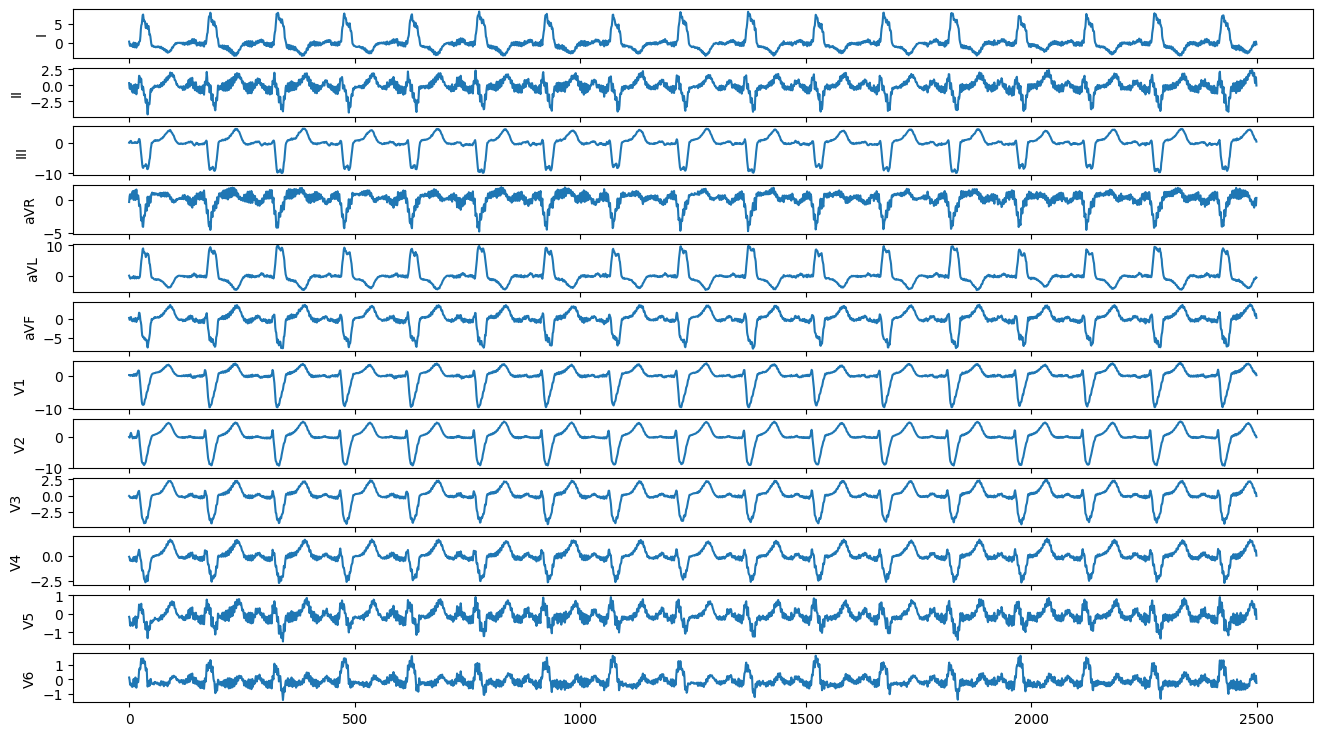

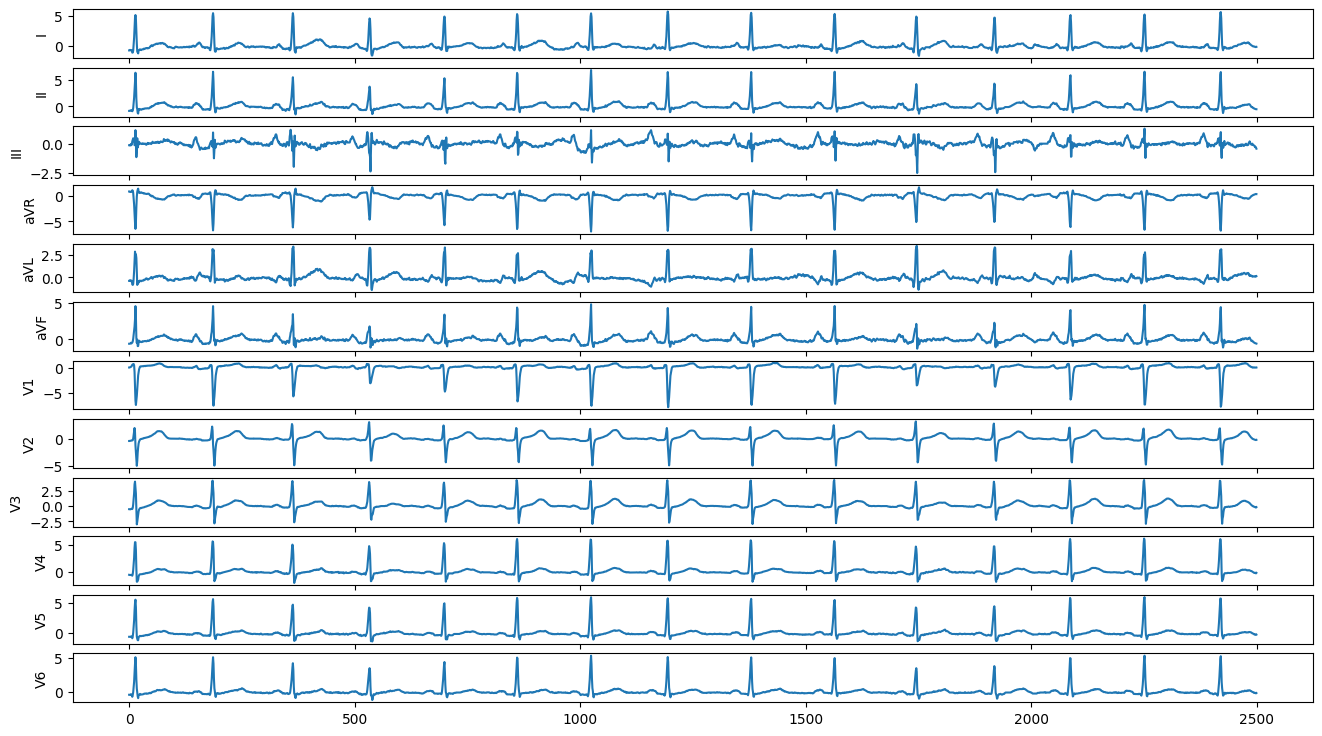

In [ ]:
# reshaped = reshaped[np.random.randint(1000)]
#To reconstruct the 12 lead ecg from the array
lead_order = ['I', 'II', 'III', 'aVR', 'aVL', 'aVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']
# plt.rcParams["figure.figsize"] = [16,9]
# fig, axs = plt.subplots(len(lead_order))
for i in range(0,2):
    plt.rcParams["figure.figsize"] = [16,9]
    fig, axs = plt.subplots(len(lead_order))
    a=np.random.randint(1000)
    print("Label Value:",labels[a])
    for i in range(0,12):
        axs[i].plot(ECG_data_1K[a,:,i])
        axs[i].set(ylabel=str(lead_order[i]))

In [ ]:


# ------------------------------------------------------------
# Basic ECG filtering
# ------------------------------------------------------------

def bandpass_filter_ecg(ecg, fs, lowcut=0.5, highcut=40.0, order=4):
    """
    Bandpass filter an ECG signal.

    Works for either:
        - 1D ECG array with shape (num_samples,)
        - 2D ECG array with shape (num_samples, num_leads)

    Parameters
    ----------
    ecg : ndarray
        ECG signal.
    fs : float
        Sampling frequency in Hz.
    lowcut : float
        Lower cutoff frequency in Hz.
    highcut : float
        Upper cutoff frequency in Hz.
    order : int
        Butterworth filter order.

    Returns
    -------
    ecg_filtered : ndarray
        Filtered ECG signal with the same shape as input.
    """
    ecg = np.asarray(ecg)

    nyquist = 0.5 * fs
    low = lowcut / nyquist
    high = highcut / nyquist

    b, a = butter(order, [low, high], btype="band")

    # axis=0 means we filter along time when ecg has shape (num_samples, num_leads)
    ecg_filtered = filtfilt(b, a, ecg, axis=0)

    return ecg_filtered


# ------------------------------------------------------------
# R-peak detection from one reference lead
# ------------------------------------------------------------

def detect_r_peaks(ecg_1d, fs, min_heart_rate=40, prominence=None, height=None):
    """
    Detect R-peaks from a single ECG lead.

    Parameters
    ----------
    ecg_1d : ndarray
        One ECG lead, shape (num_samples,).
    fs : float
        Sampling frequency in Hz.
    min_heart_rate : float
        Minimum expected heart rate in beats per minute.
    prominence : float or None
        Minimum peak prominence. If None, an automatic value is used.
    height : float or None
        Minimum peak height.

    Returns
    -------
    r_peaks : ndarray
        Indices of detected R-peaks.
    """
    ecg_1d = np.asarray(ecg_1d).ravel()

    min_distance = int(fs * 60 / min_heart_rate)

    if prominence is None:
        prominence = 0.5 * np.std(ecg_1d)

    r_peaks, _ = find_peaks(
        ecg_1d,
        distance=min_distance,
        prominence=prominence,
        height=height,
    )

    return r_peaks


# ------------------------------------------------------------
# Average heartbeat for all 12 leads
# ------------------------------------------------------------

def average_heartbeat_12lead(
    ecg_12lead,
    fs,
    r_peaks=None,
    reference_lead=1,
    pre_time=0.25,
    post_time=0.45,
):
    """
    Average multiple heartbeats for each lead of a 12-lead ECG.

    Parameters
    ----------
    ecg_12lead : ndarray
        ECG array with shape (num_samples, 12).
    fs : float
        Sampling frequency in Hz.
    r_peaks : ndarray or None
        R-peak indices. If None, R-peaks are detected from the reference lead.
    reference_lead : int
        Column index used for R-peak detection.
        For standard 12-lead order, lead II is index 1.
    pre_time : float
        Seconds before each R-peak to include.
    post_time : float
        Seconds after each R-peak to include.

    Returns
    -------
    avg_beats : ndarray
        Average heartbeat for each lead.
        Shape: (samples_per_beat, 12)

    beats : ndarray
        Individual segmented beats.
        Shape: (num_beats, samples_per_beat, 12)

    t_beat : ndarray
        Time vector for each averaged beat.
        Shape: (samples_per_beat,)

    r_peaks : ndarray
        R-peak locations used for averaging.
    """
    ecg_12lead = np.asarray(ecg_12lead)

    if ecg_12lead.ndim != 2:
        raise ValueError("ecg_12lead must be a 2D array with shape (num_samples, 12).")

    num_samples, num_leads = ecg_12lead.shape

    if num_leads != 12:
        raise ValueError(f"Expected 12 leads, but got {num_leads}.")

    if r_peaks is None:
        reference_signal = ecg_12lead[:, reference_lead]
        r_peaks = detect_r_peaks(reference_signal, fs)

    pre_samples = int(pre_time * fs)
    post_samples = int(post_time * fs)
    samples_per_beat = pre_samples + post_samples

    beats = []

    for r in r_peaks:
        start = r - pre_samples
        end = r + post_samples

        # Skip beats too close to the beginning or end
        if start >= 0 and end <= num_samples:
            beat = ecg_12lead[start:end, :]
            beats.append(beat)

    beats = np.array(beats)

    if beats.shape[0] == 0:
        raise ValueError(
            "No complete beats were found. "
            "Try changing pre_time/post_time or check R-peak detection."
        )

    avg_beats = np.mean(beats, axis=0)

    t_beat = np.arange(-pre_samples, post_samples) / fs

    return avg_beats, beats, t_beat, r_peaks


# ------------------------------------------------------------
# Plot average heartbeat for all 12 leads
# ------------------------------------------------------------

def plot_average_12lead(t_beat, avg_beats, lead_names=None):
    """
    Plot the averaged heartbeat from each of the 12 ECG leads.

    Parameters
    ----------
    t_beat : ndarray
        Time vector, shape (samples_per_beat,).
    avg_beats : ndarray
        Average beats, shape (samples_per_beat, 12).
    lead_names : list of str or None
        Names of the 12 ECG leads.
    """
    if lead_names is None:
        lead_names = [
            "I", "II", "III",
            "aVR", "aVL", "aVF",
            "V1", "V2", "V3",
            "V4", "V5", "V6",
        ]

    fig, axes = plt.subplots(4, 3, figsize=(12, 10), sharex=True)

    for lead_idx, ax in enumerate(axes.flat):
        ax.plot(t_beat, avg_beats[:, lead_idx], linewidth=2)
        ax.axvline(0, linestyle="--", linewidth=1)
        ax.set_title(f"Lead {lead_names[lead_idx]}")
        ax.grid(True)

    fig.supxlabel("Time relative to R-peak, seconds")
    fig.supylabel("ECG amplitude")
    fig.suptitle("Average Heartbeat for Each ECG Lead")
    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# Optional: Plot individual beats and average for one lead
# ------------------------------------------------------------

def plot_individual_and_average_for_lead(
    t_beat,
    beats,
    avg_beats,
    lead_idx=1,
    lead_names=None,
):
    """
    Plot all segmented beats and the average beat for one selected lead.

    Parameters
    ----------
    t_beat : ndarray
        Time vector, shape (samples_per_beat,).
    beats : ndarray
        Individual beats, shape (num_beats, samples_per_beat, 12).
    avg_beats : ndarray
        Average beats, shape (samples_per_beat, 12).
    lead_idx : int
        Lead index to plot.
    lead_names : list of str or None
        Names of ECG leads.
    """
    if lead_names is None:
        lead_names = [
            "I", "II", "III",
            "aVR", "aVL", "aVF",
            "V1", "V2", "V3",
            "V4", "V5", "V6",
        ]

    plt.figure(figsize=(10, 5))

    for k in range(beats.shape[0]):
        plt.plot(t_beat, beats[k, :, lead_idx], color="gray", alpha=0.25)

    plt.plot(
        t_beat,
        avg_beats[:, lead_idx],
        color="black",
        linewidth=3,
        label="Average beat",
    )

    plt.axvline(0, linestyle="--", color="red", label="R-peak")
    plt.xlabel("Time relative to R-peak, seconds")
    plt.ylabel("ECG amplitude")
    plt.title(f"Individual and Average Beats: Lead {lead_names[lead_idx]}")
    plt.grid(True)
    plt.legend()
    plt.show()




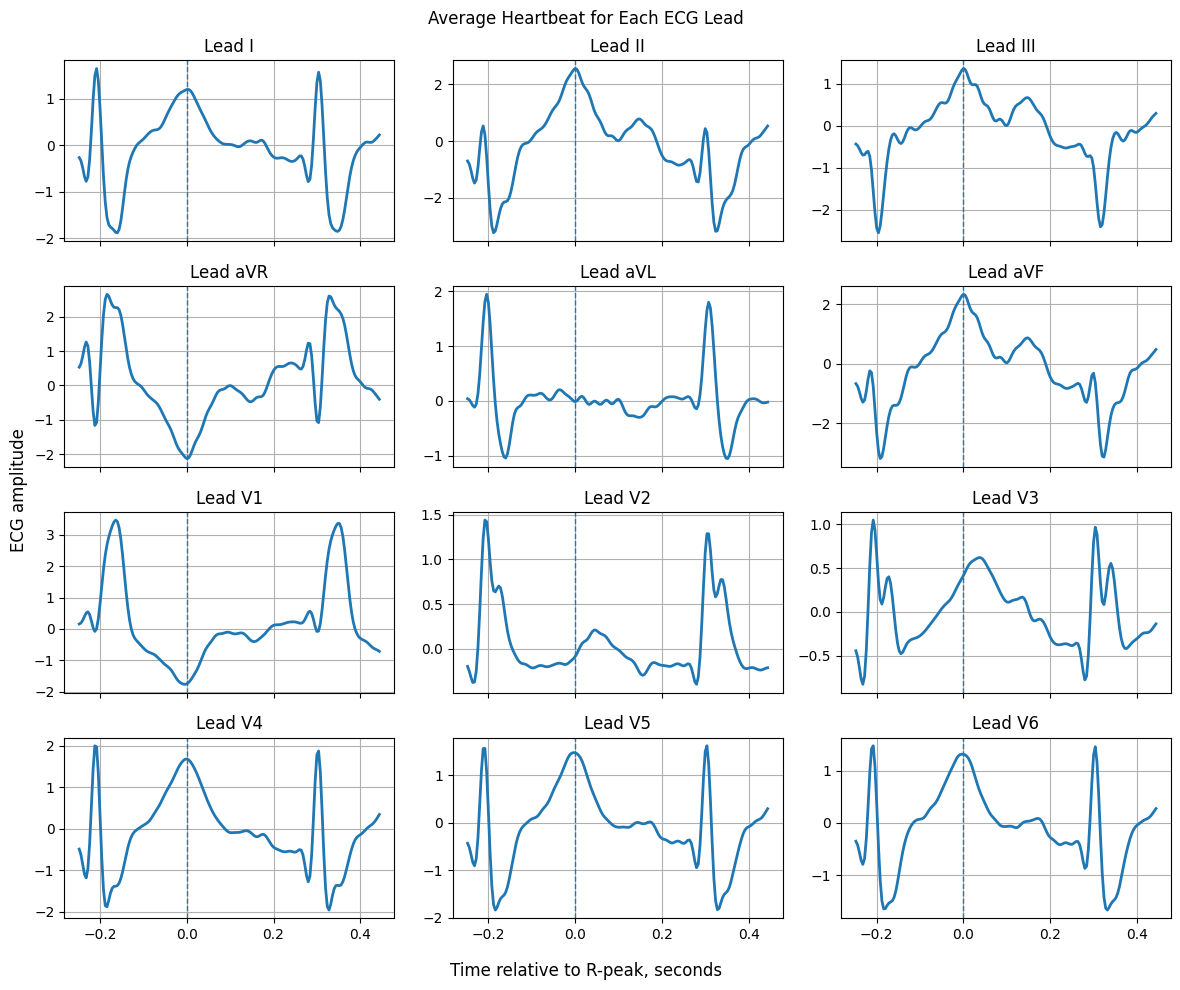

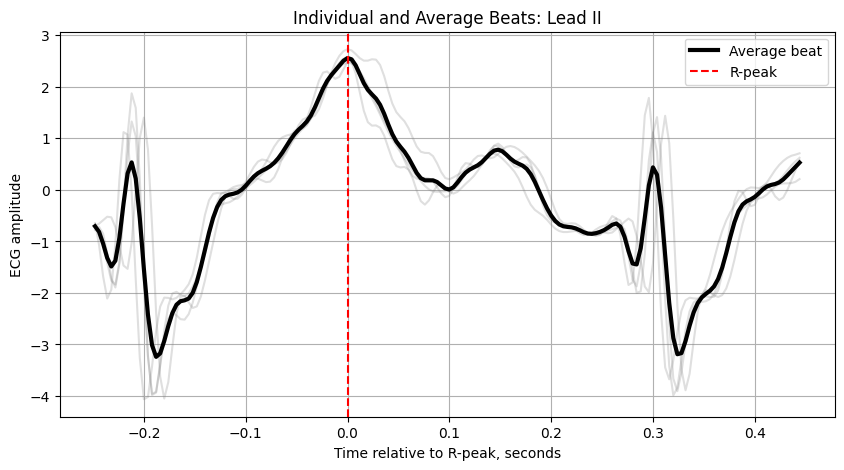

In [ ]:
# ------------------------------------------------------------
# Example usage
# ------------------------------------------------------------

# Your ECG data should have shape:
#     ecg_12lead.shape == (num_samples, 12)
#
# Example:
ecg_12lead = ECG_data_1K[0,:,:].reshape((2500,12))
fs = 250  # sampling frequency in Hz

# Step 1: Filter all leads
ecg_filtered = bandpass_filter_ecg(ecg_12lead, fs)

# Step 2: Average beats across all 12 leads
# By default, reference_lead=1, which corresponds to Lead II
# if the lead order is:
# ["I", "II", "III", "aVR", "aVL", "aVF", "V1", "V2", "V3", "V4", "V5", "V6"]

avg_beats, beats, t_beat, r_peaks = average_heartbeat_12lead(
    ecg_filtered,
    fs,
    reference_lead=1,
    pre_time=0.25,
    post_time=0.45,
)

# Step 3: Plot average beat for each lead
plot_average_12lead(t_beat, avg_beats)

# Step 4: Plot individual beats plus average for Lead II
plot_individual_and_average_for_lead(
    t_beat,
    beats,
    avg_beats,
    lead_idx=1,
)